In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
#Extract BTC-USD data from 2018-01-01 to 2024 12-31
data = yf.download(tickers = "BTC-USD", start = "2018-01-01", end = "2024-12-31" )

#print("\n")
#print(data.info)

#Extract only closing prices
close = data[('Close','BTC-USD')].to_frame("Close")

#print(data.columns)
#print(data.head())

p_t = close['Close'] # Represents today closing value
p_t_1 = close['Close'].shift(1) # Shifts series down by 1 row, a.k.a. represents yesterday closing value
log_returns = np.log(p_t/p_t_1)
#print(log_returns.head)
#print(log_returns.isna().sum())

#Calculating volatility
volatility = log_returns.rolling(window = 30).std()
#$print(volatility.head(35))

df = pd.concat([close, log_returns, volatility], axis = 1, keys = ['close', 'log_returns', 'volatility'])
df_cleaned = df.dropna()
df_cleaned.columns = df_cleaned.columns.droplevel(level = 1) # Drops second column indices
print(df_cleaned.columns.tolist())


[*********************100%***********************]  1 of 1 completed

['close', 'log_returns', 'volatility']


In [7]:
#Saving preprocessed data into csv
df_cleaned.to_csv('../data/btc_data.csv')

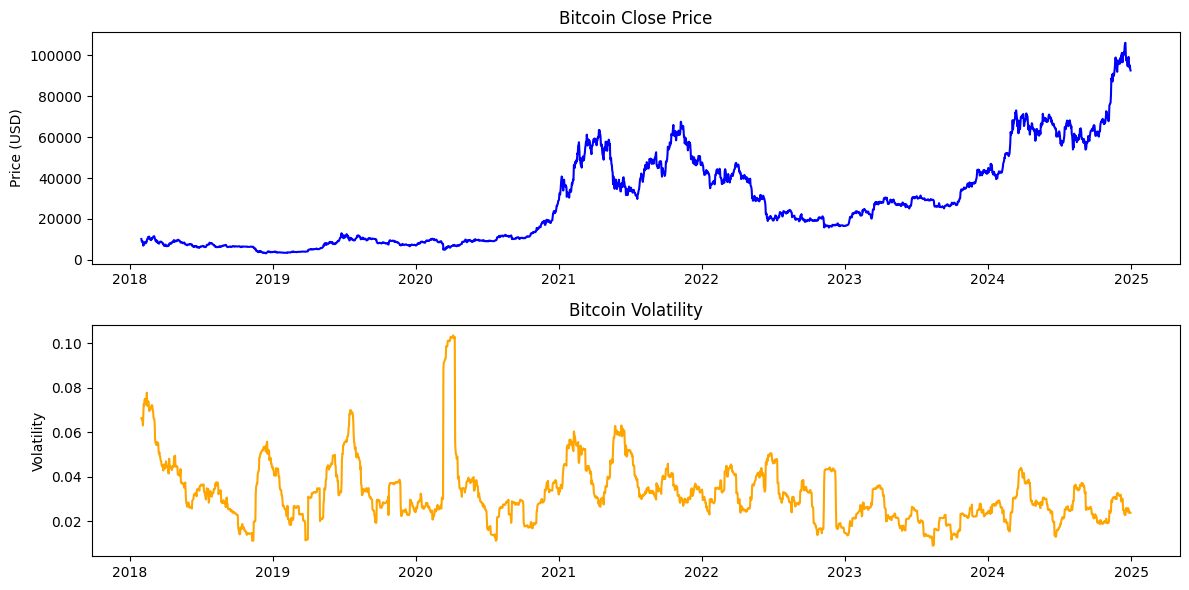

In [5]:
# Plotting BTC closing price over time and 30-day realized volatility over time

fig, axes = plt.subplots(nrows = 2, ncols = 1, figsize = (12,6))
axes[0].plot(df_cleaned['close'], color = 'blue')
axes[0].set_title('Bitcoin Close Price')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(df_cleaned['volatility'], color = 'orange')
axes[1].set_title('Bitcoin Volatility')
axes[1].set_ylabel('Volatility')

plt.tight_layout()
plt.show()


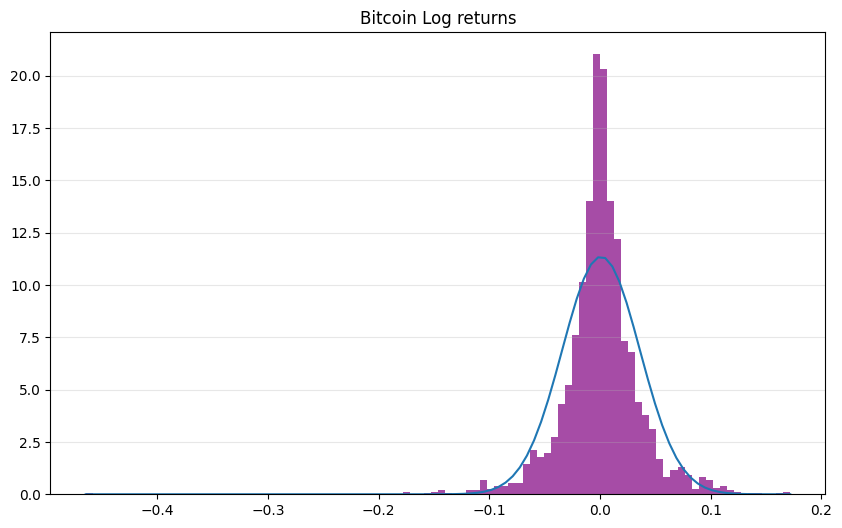

In [18]:
# Plotting histogram of log returns

plt.figure(figsize = (10,6))
plt.hist(df_cleaned['log_returns'], bins = 100, color = 'purple', alpha = 0.7, density = True)
plt.grid(axis = 'y', alpha = 0.3)
plt.title('Bitcoin Log returns')

mu, std = norm.fit(df_cleaned['log_returns'])
x = np.linspace(df_cleaned['log_returns'].min(), df_cleaned['log_returns'].max(), 100)
p = norm.pdf(x, mu, std)
plt.plot(x,p)

plt.show()

In [6]:
print(df_cleaned.index)

DatetimeIndex(['2018-01-31', '2018-02-01', '2018-02-02', '2018-02-03',
               '2018-02-04', '2018-02-05', '2018-02-06', '2018-02-07',
               '2018-02-08', '2018-02-09',
               ...
               '2024-12-21', '2024-12-22', '2024-12-23', '2024-12-24',
               '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',
               '2024-12-29', '2024-12-30'],
              dtype='datetime64[s]', name='Date', length=2526, freq=None)
